# D12 · Permutation tests must preserve the experiment

<!-- paper-first -->
### Research question

**Reading:** [PD05](../../curriculum/papers/design.md#pd05). Review the assigned figure or result before starting the lesson.

**Question:** Which rearrangements would preserve the null experiment, and which would destroy its dependence structure?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

A permutation test builds a null distribution by relabelling data in ways justified under the null and the design. It is not a general command to shuffle every row. Independent participants in an appropriate randomized between-person experiment may allow treatment-label permutations. Repeated observations from one person need restricted relabelling or a model that respects their dependence. Family, site, and longitudinal structures can require more complex exchangeability blocks.

For a paired randomized experiment, swapping the two condition labels within each person reverses that person's difference. With six people there are 2^6 possible sign patterns. Enumerating all of them gives an exact randomization distribution under the relevant sharp null and assignment scheme. For observational paired differences, a sign-flip test instead requires appropriate independence and symmetry assumptions under the tested null; it is not automatically exact simply because data came in pairs.

A permutation p value counts null statistics at least as extreme as the observed statistic, with the same one-sided or two-sided rule chosen in advance. Exact enumeration includes the observed assignment. When random permutations are sampled instead, a common finite-sampling correction is (extreme+1)/(draws+1), with details depending on the sampling scheme. Reporting p=0 after a finite number of Monte Carlo permutations overstates resolution. A two-sided absolute-value statistic does not identify which direction was predicted.

Bootstrapping asks another question. Resampling independent units with replacement approximates an estimator's sampling distribution; it does not generally construct a null distribution. For repeated measures, resample whole people with all their runs together. Resampling individual rows destroys the dependency and can underestimate uncertainty. The bootstrap is not automatically robust to outliers: an extreme observation may be sampled multiple times and strongly influence a mean. Small, biased, or unrepresentative samples remain problematic. This lab uses transparent exact sign flips and a person-level bootstrap to make the different transformations visible.

Predict the smallest possible two-sided p value for these six nonzero differences when all point in the same direction.

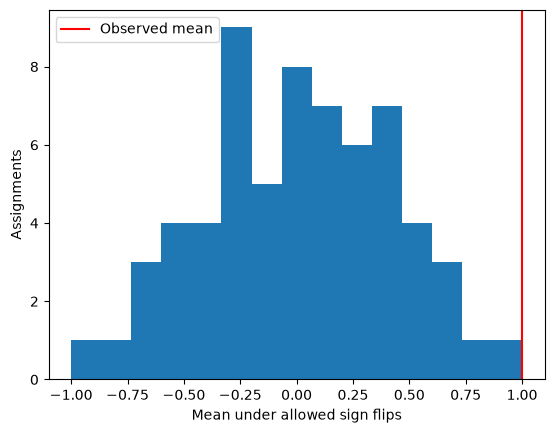

Exact two-sided p: 0.03125


In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
d=np.array([.8,1.2,.9,1.1,.7,1.3])
signs=np.array(list(itertools.product([-1,1],repeat=len(d))))
null=(signs*d).mean(axis=1)
observed=d.mean()
p=np.mean(np.abs(null)>=abs(observed)-1e-12)
assert signs.shape==(64,6)
assert np.isclose(p,2/64)
plt.hist(null,bins=15);plt.axvline(observed,color='red',label='Observed mean')
plt.xlabel('Mean under allowed sign flips');plt.ylabel('Assignments');plt.legend();plt.show()
print('Exact two-sided p:',p)

For a bootstrap, sample people, not individual runs. Identical copies make the error in naive row resampling easy to detect.

In [2]:
rng=np.random.default_rng(212)
people=np.linspace(-2,3,20)
runs=np.repeat(people[:,None],10,axis=1)
indices=rng.integers(0,len(people),size=(3000,len(people)))
correct=runs[indices].mean(axis=(1,2))
assert np.allclose(correct,people[indices].mean(axis=1))
flat=runs.ravel()
wrong=flat[rng.integers(0,len(flat),size=(3000,len(flat)))].mean(axis=1)
assert correct.std()>2.5*wrong.std()
print('Bootstrap SD, whole-person / wrong individual rows:',correct.std(),wrong.std())
finite_mc_p=(0+1)/(999+1)
assert finite_mc_p==.001
print('Zero extremes among 999 random draws does not justify p=0:',finite_mc_p)

Bootstrap SD, whole-person / wrong individual rows: 0.3385476339341982 0.1067167030601432
Zero extremes among 999 random draws does not justify p=0: 0.001


## Supervise the AI, then transfer the idea

**AI prompt:** “Before writing a permutation, list every allowed relabelling and why it represents the null. Count exact assignments for six pairs. Explain how bootstrap and permutation answer different questions. Show one short assertion that a within-person swap retains each person's owned values.”

**Deliberate mistake:** randomly shuffle all run rows and call the result distribution-free. Reject the exchangeability claim. Also reject the claim that bootstrapping a mean is automatically resistant to outliers. In real fMRI, do not permute autocorrelated scan times arbitrarily. With nuisance variables, unequal variances, or several nested dependence levels, use a justified procedure such as an appropriate residual-based or blocked method rather than inventing a shuffle. Deliver an exchangeability diagram, test statistic, tail rule, number of permutations, and minimum resolvable p value.

## Answer key — read after your own explanation

The exact p value is 2/64=.03125: all-positive and all-negative patterns are equally extreme. Whole-person bootstrap preserves identical runs within a participant; row bootstrap fabricates extra independent information and is too narrow here. Bootstrap samples contain duplicates by construction and can repeat outliers. Nuisance adjustment changes permutation validity; a naive label shuffle is not automatically valid after arbitrary regression.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [DartBrains Resampling Statistics, pinned upstream notebook](https://github.com/ljchang/dartbrains/blob/b72537ad25deee0281248a415a052cd87ff325de/content/Resampling_Statistics.ipynb); [FSL randomise, theory and repeated measurements](https://fsl.fmrib.ox.ac.uk/fsl/docs/statistics/randomise.html). The upstream notebook is preserved unmodified in third_party; its blanket robustness claim about bootstrap outliers should not be adopted. See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Revisit [PD05](../../curriculum/papers/design.md#pd05) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
